In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

from collections import OrderedDict
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

In [2]:
from dehar.satellite.load_satellite_stacks import load_s2

BASELINE_YEARS = range(2017, 2025)
TARGET_YEAR    = 2025
TOWER_X, TOWER_Y = 395509.71, 5309956.22
MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

In [3]:
# Paths
ROOT_DIR = Path.cwd().parent.parent.parent
fluxes_path = ROOT_DIR / "data" / "processed" / "atmosphere_soil" / "fluxes_dehar_30min.csv"
precip_path = ROOT_DIR / "data" / "processed" / "atmosphere_soil" / "HARTHM_2025_Precipitation_30min_UTC.csv"
meteo_path = ROOT_DIR / "data" / "processed" / "atmosphere_soil" / "meteo_dehar_30min.csv"
soil_moisture_path = ROOT_DIR / "data" / "processed" / "atmosphere_soil" / "soil_moisture_dehar_30min.csv"

# Physiology
sap_flow_path = ROOT_DIR / "data" / "processed" / "physiology" / "sap_flux_density" / "sapflow_dehar_30min.csv"
swp_path = ROOT_DIR / "data" / "processed" / "physiology" / "stemwater_potential" / "swp_dehar_15min.csv"
twd_path = ROOT_DIR / "data" / "processed" / "physiology" / "twd" / "twd_dehar_30min.csv"

# VOD
vod_path = ROOT_DIR / "data" / "processed" / "proximal_rs" / "gnss_vod" / "gnss_vod_dehar_30min.csv"

# Leaf
leaf_path = ROOT_DIR / "data" / "processed" / "proximal_rs" / "leaf" / "leaf_hemi_low_2025.parquet"

# Satellite
sentinel_2_dir = ROOT_DIR / "data" / "raw" / "satellite" / "sentinel2"
sentinel_1_dir = ROOT_DIR / "data" / "raw" / "satellite" / "sentinel1"

In [4]:
# Load data — sep=',' for all files, datetime as index
fluxes = pd.read_csv(fluxes_path, sep=",", parse_dates=["datetime"], index_col="datetime")
meteo = pd.read_csv(meteo_path, sep=",", parse_dates=["datetime"], index_col="datetime")
soil_moisture = pd.read_csv(soil_moisture_path, sep=",", parse_dates=["datetime"], index_col="datetime")

# Precipitation: use the ISO "From" column as datetime
precip = pd.read_csv(precip_path, sep=",", parse_dates=["From"], index_col="From")
precip.index.name = "datetime"
precip = precip[["Precipitation_Sum_mm"]]

# Physiology
sap_flow = pd.read_csv(sap_flow_path, sep=",", parse_dates=["datetime"], index_col="datetime")
swp = pd.read_csv(swp_path, sep=",", parse_dates=["datetime"], index_col="datetime")   # 15-min resolution
twd = pd.read_csv(twd_path, sep=",", parse_dates=["datetime"], index_col="datetime")

# VOD
vod = pd.read_csv(vod_path, sep=",", parse_dates=["datetime"], index_col="datetime")

# Leaf
leaf = pd.read_parquet(leaf_path, engine="pyarrow")
leaf["datetime"] = pd.to_datetime(leaf["datetime"])
leaf.set_index("datetime", inplace=True)

In [5]:
sentinel_2 = load_s2(sentinel_2_dir)

In [ ]:
import spyndex

spyndex.indices

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import spyndex

# Spyndex index names to compute
#S2_INDICES = ["NDVI", "kNDVI", "EVI", "CIRE", "MTCI", "MSI", "GVMI", "SAVI", "MCARI", "NDWI", "GNDVI", "NIRv"]
S2_INDICES = ["NDVI", "kNDVI", "EVI", "NIRv", "SAVI", "CIRE", "MTCI", "NDII"] #"MCARI"

def _normalize_dims(ds: xr.Dataset) -> xr.Dataset:
    rename = {}
    if "X" in ds.dims and "x" not in ds.dims:
        rename["X"] = "x"
    if "Y" in ds.dims and "y" not in ds.dims:
        rename["Y"] = "y"
    return ds.rename(rename) if rename else ds

def load_s2_processed_indices(data_dir: Path) -> xr.Dataset:
    files = sorted(Path(data_dir).glob("s2_sr_dehar_*_indices.nc"))
    if not files:
        raise FileNotFoundError(f"No files matching {data_dir}/s2_sr_dehar_*_indices.nc")
    dsets = [_normalize_dims(xr.open_dataset(f)) for f in files]
    ds = xr.concat(dsets, dim="time").sortby("time")
    _, idx = np.unique(ds.time.values, return_index=True)
    return ds.isel(time=idx)


def add_spyndex_indices(ds: xr.Dataset, indices: list[str] = S2_INDICES) -> xr.Dataset:
    """
    Compute spectral indices via spyndex (doi:10.1038/s41597-023-02096-0).
    Each index is computed individually so conflicting constants (e.g. L for
    EVI vs SAVI) are resolved automatically from the spyndex catalogue defaults.

    Spyndex parameter → S2 band:
      N   = B8   (NIR broad)       N2  = B8A  (NIR narrow)
      R   = B4   (Red)             G   = B3   (Green)
      B   = B2   (Blue)            RE1 = B5   (Red Edge 1)
      RE2 = B6   (Red Edge 2)      S1  = B11  (SWIR 1)
      S2  = B12  (SWIR 2)
    """
    sc = 10000.0
    ds = ds / sc if ds["B2"].max() > 2.0 else ds
    
    kNR = spyndex.computeKernel(
        kernel="RBF",
        params={
            "a":     ds["B8"].astype("float32"),
            "b":     ds["B4"].astype("float32"),
            "sigma": float(np.abs(ds["B8"] - ds["B4"]).median().item()),
        },
    )

    band_params = {
        "N":   ds["B8"].astype("float32"),
        "N2":  ds["B8A"].astype("float32"),
        "R":   ds["B4"].astype("float32"),
        "G":   ds["B3"].astype("float32"),
        "B":   ds["B2"].astype("float32"),
        "RE1": ds["B5"].astype("float32"),
        "RE2": ds["B6"].astype("float32"),
        "S1":  ds["B11"].astype("float32"),
        "S2":  ds["B12"].astype("float32"),
        "kNN": 1.0,
        "kNR": kNR,
    }

    for name in indices:
        # build per-index params: bands + auto-fetched catalogue defaults for constants
        params = dict(band_params)
        for p in spyndex.indices[name].bands:
            if p not in params and p in spyndex.constants:
                params[p] = spyndex.constants[p].default

        ds[name] = spyndex.computeIndex(index=name, params=params, online=False)

    return ds

def s2_circle_timeseries_stats(
    data_dir: Path,
    year: int = 2025,
    x: float = 395_509.71,
    y: float = 5_309_956.22,
    radius_m: float = 100.0,
    indices: list[str] = S2_INDICES,   # ← add this
):
    ds = load_s2_processed_indices(data_dir)
    ds = add_spyndex_indices(ds, indices=indices)
    ds_year = ds.sel(time=ds.time.dt.year == year)

    mask = ((ds_year.x - x) ** 2 + (ds_year.y - y) ** 2) <= (radius_m ** 2)
    n_pix = int(mask.sum().item())

    vars_xyz = [
        v for v in ds_year.data_vars
        if {"time", "x", "y"}.issubset(set(ds_year[v].dims))
        and v in indices   # ← only keep the spyndex-computed ones
    ]
    roi = ds_year[vars_xyz].where(mask)
    mean_df = roi.mean(dim=("x", "y"), skipna=True).to_dataframe().add_suffix("_mean")
    std_df  = roi.std(dim=("x", "y"), skipna=True).to_dataframe().add_suffix("_std")
    df = mean_df.join(std_df).sort_index()
    df.index.name = "datetime"
    return ds_year, mask, df, n_pix

In [7]:
sentinel_2_dir = ROOT_DIR / "data" / "processed" / "satellite" / "sentinel2"

sentinel_2_2025, footprint_mask, s2_stats_2025, n_pixels = s2_circle_timeseries_stats(
    data_dir=sentinel_2_dir,
    year=2025,
    x=TOWER_X,
    y=TOWER_Y,
    radius_m=50,   # change this to any circle size you want
)

# Filter stats to manually verified clear-sky dates
dates_to_consider = ["2025-01-13", "2025-02-27", "2025-03-04", "2025-03-09", "2025-03-19", "2025-04-03", "2025-04-08", "2025-04-10", "2025-04-28", "2025-04-30", "2025-05-10", "2025-05-20", "2025-05-30", "2025-06-09", "2025-06-12", "2025-06-17", "2025-06-19", "2025-06-22", "2025-06-29", "2025-07-02", "2025-08-08", "2025-08-11", "2025-08-18", "2025-08-26", "2025-08-31", "2025-09-20", "2025-10-07", "2025-10-15", "2025-10-30", "2025-11-04", "2025-11-06", "2025-11-19", "2025-12-09"] #"2025-09-27", "2025-09-07" #"2025-05-18""2025-07-29",#"2025-07-12"
_good = pd.to_datetime(dates_to_consider).normalize()
_idx_norm = s2_stats_2025.index.normalize() if hasattr(s2_stats_2025.index, "normalize") else pd.to_datetime(s2_stats_2025.index).normalize()

s2_stats_2025_clean = s2_stats_2025[_idx_norm.isin(_good)]

print(f"Kept {len(s2_stats_2025_clean)} of {len(s2_stats_2025)} timesteps")
s2_stats_2025_clean.head()

Kept 33 of 102 timesteps


,NDVI_mean,EVI_mean,kNDVI_mean,NIRv_mean,SAVI_mean,CIRE_mean,MTCI_mean,NDII_mean,NDVI_std,EVI_std,kNDVI_std,NIRv_std,SAVI_std,CIRE_std,MTCI_std,NDII_std
datetime,,,,,,,,,,,,,,,,
2025-01-13 10:37:34.949,0.716591,0.246542,0.203000,0.103277,0.204305,1.899513,2.107861,0.215505,0.058758,0.050769,0.081629,0.025098,0.041647,0.450796,0.468691,0.089921
2025-02-27 10:37:59.976,0.542560,0.282121,0.229305,0.099525,0.207236,1.011883,1.441056,0.097652,0.044352,0.045304,0.075224,0.020029,0.033482,0.228059,0.301085,0.069006
2025-03-04 10:37:38.912,0.546444,0.255727,0.214288,0.096721,0.202751,1.105016,1.641220,0.021840,0.045027,0.033623,0.056101,0.015727,0.026173,0.231023,0.455603,0.057672
2025-03-09 10:37:59.402,0.566986,0.236302,0.193239,0.092823,0.195124,1.038857,1.446490,-0.006742,0.048765,0.033352,0.053313,0.015771,0.026440,0.238684,0.355561,0.062833
2025-03-19 10:37:59.665,0.591498,0.241676,0.206755,0.097672,0.202411,1.135749,1.488656,-0.000456,0.054846,0.032188,0.053686,0.015776,0.026204,0.231425,0.409128,0.063888


In [8]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_all_indices_with_std(
    df: pd.DataFrame,
    start: str | None = None,
    end: str | None = None,
    ncols: int = 3,
    figsize_per_panel: tuple[float, float] = (5.5, 3.2),
    include_bands: bool = False,
):
    """
    Plot all Sentinel-2 time series with mean ± std from columns:
      <var>_mean, <var>_std
    """

    # 1) prepare frame
    data = df.copy().sort_index()
    if start is not None or end is not None:
        data = data.loc[start:end]

    if not isinstance(data.index, pd.DatetimeIndex):
        data.index = pd.to_datetime(data.index)

    # 2) detect available pairs
    mean_cols = [c for c in data.columns if c.endswith("_mean")]
    names = [c[:-5] for c in mean_cols if f"{c[:-5]}_std" in data.columns]

    # optional: exclude raw S2 bands (B2, B3, ..., B12, B8A)
    if not include_bands:
        names = [n for n in names if not (len(n) >= 2 and n[0] == "B" and n[1].isdigit())]

    if len(names) == 0:
        raise ValueError("No <name>_mean / <name>_std pairs found.")

    # 3) layout
    n = len(names)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        sharex=True,
    )

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    # 4) plot each variable
    for i, name in enumerate(names):
        ax = axes[i]

        m = data[f"{name}_mean"].astype(float)
        s = data[f"{name}_std"].astype(float)

        lower = (m - s).to_numpy()
        upper = (m + s).to_numpy()
        finite = np.isfinite(lower) & np.isfinite(upper) & np.isfinite(m.to_numpy())

        ax.plot(m.index, m.to_numpy(), lw=1.5, label="mean")
        ax.fill_between(m.index, lower, upper, where=finite, alpha=0.25, label="±1 std")

        ax.set_title(name)
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8, loc="best")

        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    # 5) hide unused axes
    for j in range(len(names), len(axes)):
        axes[j].axis("off")

    fig.suptitle("Sentinel-2 footprint time series (mean ± std)", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()

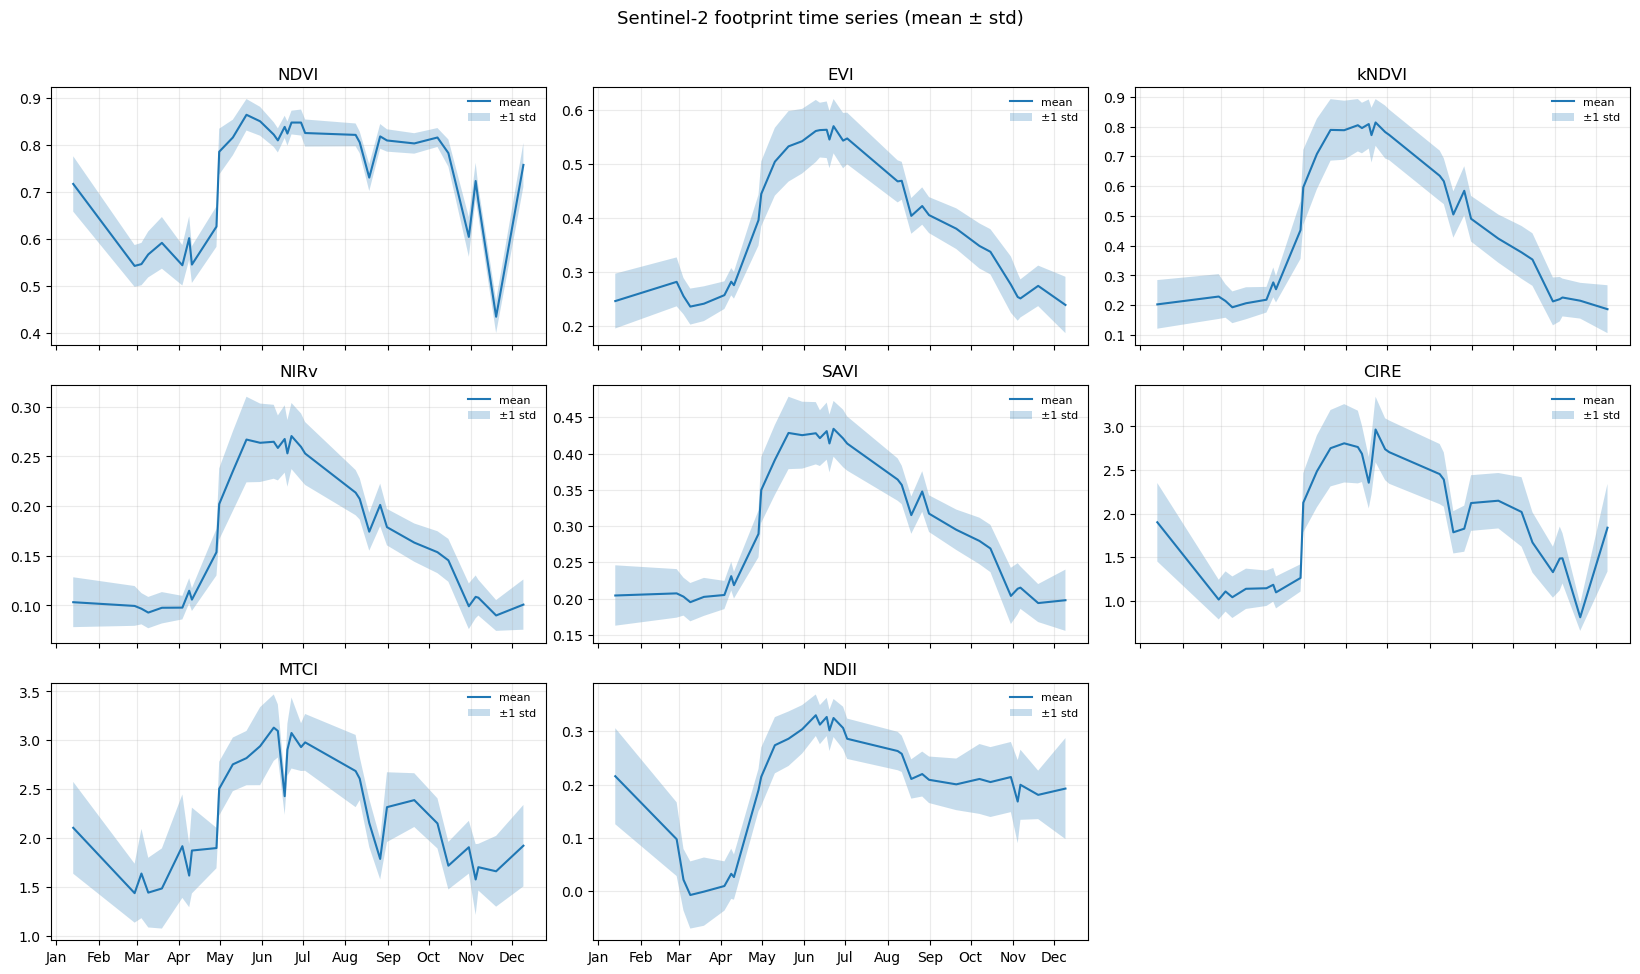

In [10]:
plot_all_indices_with_std(
    s2_stats_2025_clean,
    start="2025-01-01",
    end="2025-12-31",
    ncols=3,
    include_bands=False,   # True if you also want B2..B12
)

In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_s2_rgb_scenes(
    data_dir: Path,
    year: int = 2025,
    x: float = TOWER_X,
    y: float = TOWER_Y,
    buffer_m: float = 100.0,
    vmax: float = 3000.0,
    gamma: float = 1.4,
    ncols: int = 6,
):
    """
    Plot all cloud-masked Sentinel-2 RGB (B4/B3/B2) scenes for a given year
    cropped to buffer_m around the tower. Red cross = tower location.
    Completely-masked scenes (all NaN) are shown grey with '(masked)' label.
    """
    ds = load_s2_processed_indices(data_dir)   # already defined in your helper cell
    ds_year = ds.sel(time=ds.time.dt.year == year)

    # ── crop to square buffer ──────────────────────────────────────────────
    x_min, x_max = x - buffer_m, x + buffer_m
    y_min, y_max = y - buffer_m, y + buffer_m

    y_vals = ds_year.y.values
    if y_vals[0] > y_vals[-1]:          # descending (common for rasters)
        roi = ds_year.sel(x=slice(x_min, x_max), y=slice(y_max, y_min))
    else:                               # ascending
        roi = ds_year.sel(x=slice(x_min, x_max), y=slice(y_min, y_max))

    n_scenes = roi.sizes["time"]
    nrows = math.ceil(n_scenes / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 2.8, nrows * 3.0),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for i in range(n_scenes):
        ax = axes_flat[i]
        scene = roi.isel(time=i)
        date_str = str(scene.time.values)[:10]

        r = scene["B4"].values.astype(float)
        g = scene["B3"].values.astype(float)
        b = scene["B2"].values.astype(float)

        rgb = np.stack([r, g, b], axis=-1)

        # check if scene is completely masked
        all_nan = False #~np.isfinite(rgb).any()
        if all_nan:
            ax.imshow(np.full((*rgb.shape[:2], 3), 0.65), vmin=0, vmax=1)
            ax.set_title(f"{date_str}\n(masked)", fontsize=7, color="grey")
        else:
            rgb = np.clip(rgb / vmax, 0, 1) ** (1.0 / gamma)
            #nan_mask = ~np.isfinite(rgb).all(axis=-1)
            #rgb[nan_mask] = 0.65          # grey fill for masked pixels

            ax.imshow(rgb, interpolation="nearest")
            ax.set_title(date_str, fontsize=7)

        # tower cross
        xs = roi.x.values
        ys = roi.y.values
        ix = int(np.argmin(np.abs(xs - x)))
        iy = int(np.argmin(np.abs(ys - y)))
        ax.plot(ix, iy, "r+", ms=10, mew=1.8)
        ax.axis("off")

    for j in range(n_scenes, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(
        f"Sentinel-2 RGB (B4/B3/B2) — {year}  |  {int(buffer_m*2)}×{int(buffer_m*2)} m around tower",
        fontsize=12, y=1.005,
    )
    plt.tight_layout()
    plt.show()
    print(f"Total scenes: {n_scenes}")

In [12]:
plot_s2_rgb_scenes(
    data_dir=sentinel_2_dir,
    year=2025,
    buffer_m=200,
    ncols=6,
    vmax=3000,
    gamma=1.6,   # >1 brightens the image
)

KeyboardInterrupt: 

Total scenes: 102
  Masked (all-NaN): 0
  Valid           : 102

── Masked scene dates ──────────────────────────────────────────────
Empty DataFrame
Columns: [rg_wm2, rh_pct, vpd_hpa, tair_c, Precipitation_Sum_mm]
Index: []

── Valid scene dates ───────────────────────────────────────────────
                rg_wm2     rh_pct    vpd_hpa     tair_c  Precipitation_Sum_mm
date                                                                         
2025-01-03   63.196103  94.198833   0.348529  -0.504270                  2.21
2025-01-08    9.810949  89.839479   1.034110   6.277605                 10.31
2025-01-13   81.522542  84.787375   0.800428  -3.227038                  0.00
2025-01-18   58.792687  87.948562   0.779204  -0.296142                  0.00
2025-01-23   57.071252  83.982646   1.510786   5.977013                  3.43
2025-01-28   49.968473  73.507021   2.972119   7.980193                  1.26
2025-02-02   28.406939  83.080583   1.246485   2.298690                  0.00
202

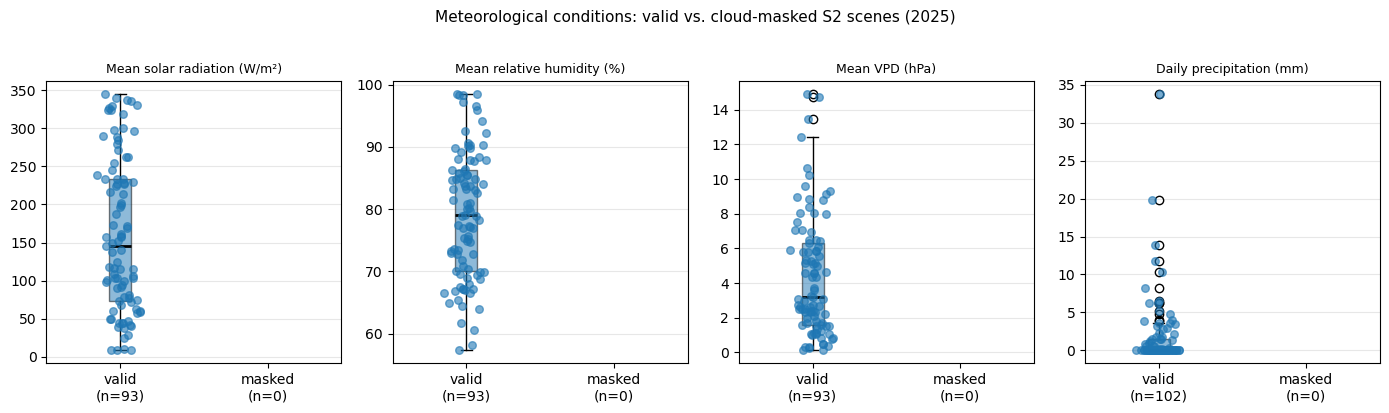

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 1. identify masked vs valid scene dates ───────────────────────────────
scene_dates = pd.to_datetime(
    [str(t)[:10] for t in sentinel_2_2025.time.values]
)

# A scene is "masked" if NDVI_mean is NaN in s2_stats_2025
ndvi_mean = s2_stats_2025["NDVI_mean"]
masked_dates = pd.to_datetime(
    [str(t)[:10] for t in ndvi_mean[ndvi_mean.isna()].index]
)
valid_dates = pd.to_datetime(
    [str(t)[:10] for t in ndvi_mean[ndvi_mean.notna()].index]
)

print(f"Total scenes: {len(scene_dates)}")
print(f"  Masked (all-NaN): {len(masked_dates)}")
print(f"  Valid           : {len(valid_dates)}")

# ── 2. build daily meteo aggregates ──────────────────────────────────────
meteo_d = meteo.copy()
meteo_d.index = meteo_d.index.tz_localize(None) if meteo_d.index.tzinfo else meteo_d.index
meteo_daily = meteo_d.resample("1D").agg({
    "rg_wm2":   "mean",    # mean daytime radiation
    "rh_pct":   "mean",
    "vpd_hpa":  "mean",
    "tair_c":   "mean",
})

# precipitation daily sum
precip_d = precip.copy()
precip_d.index = precip_d.index.tz_localize(None) if precip_d.index.tzinfo else precip_d.index
precip_daily = precip_d.resample("1D").sum()

daily = meteo_daily.join(precip_daily, how="outer")

# ── 3. lookup conditions on scene dates ───────────────────────────────────
def lookup(dates):
    idx = pd.DatetimeIndex(dates).normalize()
    return daily.reindex(idx).assign(date=idx).set_index("date")

df_masked = lookup(masked_dates)
df_valid  = lookup(valid_dates)

print("\n── Masked scene dates ──────────────────────────────────────────────")
print(df_masked[["rg_wm2","rh_pct","vpd_hpa","tair_c","Precipitation_Sum_mm"]].to_string())

print("\n── Valid scene dates ───────────────────────────────────────────────")
print(df_valid[["rg_wm2","rh_pct","vpd_hpa","tair_c","Precipitation_Sum_mm"]].to_string())

# ── 4. comparison plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

vars_labels = [
    ("rg_wm2",              "Mean solar radiation (W/m²)"),
    ("rh_pct",              "Mean relative humidity (%)"),
    ("vpd_hpa",             "Mean VPD (hPa)"),
    ("Precipitation_Sum_mm","Daily precipitation (mm)"),
]

for ax, (col, label) in zip(axes, vars_labels):
    m_vals = df_masked[col].dropna()
    v_vals = df_valid[col].dropna()

    ax.boxplot(
        [v_vals, m_vals],
        labels=["valid\n(n=%d)" % len(v_vals), "masked\n(n=%d)" % len(m_vals)],
        patch_artist=True,
        boxprops=dict(facecolor="C0", alpha=0.5),
        medianprops=dict(color="k", lw=2),
    )
    # overlay scatter
    np.random.seed(0)
    for k, vals in enumerate([v_vals, m_vals], start=1):
        jitter = np.random.normal(k, 0.06, len(vals))
        ax.scatter(jitter, vals, s=30, alpha=0.6,
                   color="C0" if k == 1 else "C1", zorder=3)

    ax.set_title(label, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Meteorological conditions: valid vs. cloud-masked S2 scenes (2025)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Sentinel-1

In [32]:
import xarray as xr
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
#from dehar.satellite.sentinel1 import add_all_indices

S1_INDICES = ["RVI", "SPAN", "VH_VV_ratio"]   # CR = VH_VV_ratio (dB log of γ_VH/γ_VV)

def add_all_indices(ds):
    vv_lin = _db_to_linear(ds["VV"])
    vh_lin = _db_to_linear(ds["VH"])
    ds["VV_lin"]  = vv_lin
    ds["VH_lin"]  = vh_lin
    ds["SPAN_lin"] = vv_lin + vh_lin
    ds["CR_lin"]   = vh_lin / vv_lin.where(vv_lin > 0)
    ds["RVI"]      = 4 * vh_lin / (vv_lin + vh_lin)
    return ds

def _db_to_linear(da):
    """dB → linear power."""
    return 10 ** (da / 10)

def load_s1_orbit(data_dir, year: int, orbit: str):
    """Load one orbit track ('a'=ascending, 'd'=descending) for a given year."""
    f = sorted(data_dir.glob(f"s1_grd_dehar_{orbit}_{year}.nc"))
    if not f:
        raise FileNotFoundError(f"No S1 file for orbit={orbit}, year={year}")
    ds = xr.open_dataset(f[0])
    # normalise dim names
    rename = {k: k.lower() for k in ds.dims if k in ("X", "Y")}
    if rename:
        ds = ds.rename(rename)
    return ds

def s1_circle_timeseries_stats(
    data_dir,
    year: int = 2025,
    x: float = TOWER_X,
    y: float = TOWER_Y,
    radius_m: float = 100.0,
    indices: list[str] = S1_INDICES,
):
    # work in linear space, convert to dB only at the end
    linear_vars = ["VV_lin", "VH_lin", "SPAN_lin", "CR_lin", "RVI"]

    results = {}
    for orbit, label in [("a", "ascending"), ("d", "descending")]:
        ds = load_s1_orbit(data_dir, year, orbit)
        
        THETA_REF = 40.0  # reference angle in degrees
        N = 2  # exponent; 2 is standard for vegetation, some papers use 1

        def angle_normalize(vv_db, vh_db, angle_deg, theta_ref=THETA_REF, n=N):
            """
            Cosine-law angle normalization for vegetation.
            sigma0(theta_ref) = sigma0(theta) * (cos(theta_ref)/cos(theta))**n
            Applied in dB: add 10*n*log10(cos(theta_ref)/cos(theta)).
            """
            theta = np.deg2rad(angle_deg)
            theta_r = np.deg2rad(theta_ref)
            correction_db = 10 * n * np.log10(np.cos(theta_r) / np.cos(theta))
            return vv_db + correction_db, vh_db + correction_db

        # apply before add_all_indices:
        ds["VV"], ds["VH"] = angle_normalize(ds["VV"], ds["VH"], ds["angle"])
        
        ds = add_all_indices(ds)   # must produce the *_lin variables
        ds_year = ds.sel(time=ds.time.dt.year == year)

        mask = ((ds_year.x - x) ** 2 + (ds_year.y - y) ** 2) <= radius_m ** 2

        vars_xyz = [
            v for v in ds_year.data_vars
            if {"time", "x", "y"}.issubset(set(ds_year[v].dims)) and v in linear_vars
        ]
        roi = ds_year[vars_xyz].where(mask)

        mean_df = roi.mean(dim=("x", "y"), skipna=True).to_dataframe().add_suffix("_mean")
        std_df  = roi.std( dim=("x", "y"), skipna=True).to_dataframe().add_suffix("_std")
        df = mean_df.join(std_df).sort_index()
        df.index.name = "datetime"

        # ── convert aggregated linear quantities to dB for display ──
        df["VV_dB_mean"]   = 10 * np.log10(df["VV_lin_mean"])
        df["VH_dB_mean"]   = 10 * np.log10(df["VH_lin_mean"])
        df["SPAN_dB_mean"] = 10 * np.log10(df["SPAN_lin_mean"])
        df["CR_dB_mean"]   = 10 * np.log10(df["CR_lin_mean"])

        # propagate std from linear to dB:  σ_dB ≈ (10/ln10) · σ_lin / mean_lin
        k = 10 / np.log(10)
        df["VV_dB_std"]   = k * df["VV_lin_std"]   / df["VV_lin_mean"]
        df["VH_dB_std"]   = k * df["VH_lin_std"]   / df["VH_lin_mean"]
        df["SPAN_dB_std"] = k * df["SPAN_lin_std"] / df["SPAN_lin_mean"]
        df["CR_dB_std"]   = k * df["CR_lin_std"]   / df["CR_lin_mean"]

        # RVI is already dimensionless/linear — no conversion needed
        # df["RVI_mean"] and df["RVI_std"] come through unchanged

        results[label] = df

    return results

s1_stats_2025 = s1_circle_timeseries_stats(
    data_dir=sentinel_1_dir,
    year=2025,
    x=TOWER_X,
    y=TOWER_Y,
    radius_m=100,
)

print("Ascending  :", len(s1_stats_2025["ascending"]), "scenes")
print("Descending :", len(s1_stats_2025["descending"]), "scenes")
s1_stats_2025["ascending"].head()

Ascending  : 51 scenes
Descending : 49 scenes


,VV_lin_mean,VH_lin_mean,SPAN_lin_mean,CR_lin_mean,RVI_mean,VV_lin_std,VH_lin_std,SPAN_lin_std,CR_lin_std,RVI_std,VV_dB_mean,VH_dB_mean,SPAN_dB_mean,CR_dB_mean,VV_dB_std,VH_dB_std,SPAN_dB_std,CR_dB_std
datetime,,,,,,,,,,,,,,,,,,
2025-01-10 17:24:09,0.102332,0.029482,0.131814,0.310337,0.913288,0.032273,0.012308,0.037084,0.143550,0.314938,-9.899879,-15.304404,-8.800374,-5.081658,1.369677,1.813024,1.221813,2.008871
2025-01-22 17:24:08,0.110631,0.027870,0.138501,0.262818,0.811008,0.028346,0.010521,0.032151,0.108610,0.251493,-9.561227,-15.548686,-8.585479,-5.803457,1.112761,1.639482,1.008152,1.794728
2025-02-03 17:24:08,0.111209,0.033812,0.145021,0.332790,0.966418,0.035779,0.010738,0.039175,0.144197,0.302241,-9.538599,-14.709294,-8.385690,-4.778303,1.397242,1.379237,1.173162,1.881783
2025-02-15 17:24:07,0.113706,0.034198,0.147904,0.336015,0.971601,0.039802,0.009006,0.042033,0.150413,0.309161,-9.442171,-14.659999,-8.300206,-4.736409,1.520234,1.143705,1.234221,1.944066
2025-02-27 17:24:07,0.123833,0.036157,0.159991,0.313649,0.924400,0.036560,0.013057,0.040368,0.136362,0.298098,-9.071626,-14.418025,-7.959052,-5.035565,1.282191,1.568319,1.095798,1.888141


In [27]:
RAIN_THRESH_MM = 1.0   # scenes where daily precip > this are dropped

def filter_rainy_scenes(df_stats, precip_daily, thresh_mm=RAIN_THRESH_MM):
    idx_norm = df_stats.index.normalize()
    if idx_norm.tz is not None:
        idx_norm = idx_norm.tz_localize(None)
    rain_on_scene = precip_daily.reindex(idx_norm).values
    matched = np.isfinite(rain_on_scene).sum()
    if matched == 0:
        print("⚠ no precip dates matched — check timezone / date alignment")
    dry = (rain_on_scene <= thresh_mm) | np.isnan(rain_on_scene)
    return df_stats[dry], (~dry).sum()

precip_daily_series = precip["Precipitation_Sum_mm"].resample("1D").sum()
precip_daily_series.index = precip_daily_series.index.tz_localize(None) \
    if precip_daily_series.index.tzinfo else precip_daily_series.index

s1_stats_2025_dry = {}
for orbit, df in s1_stats_2025.items():
    filtered, n_dropped = filter_rainy_scenes(df, precip_daily_series)
    s1_stats_2025_dry[orbit] = filtered
    print(f"{orbit}: {len(df)} scenes → {len(filtered)} kept, {n_dropped} rainy dropped")

ascending: 51 scenes → 36 kept, 15 rainy dropped
descending: 49 scenes → 33 kept, 16 rainy dropped


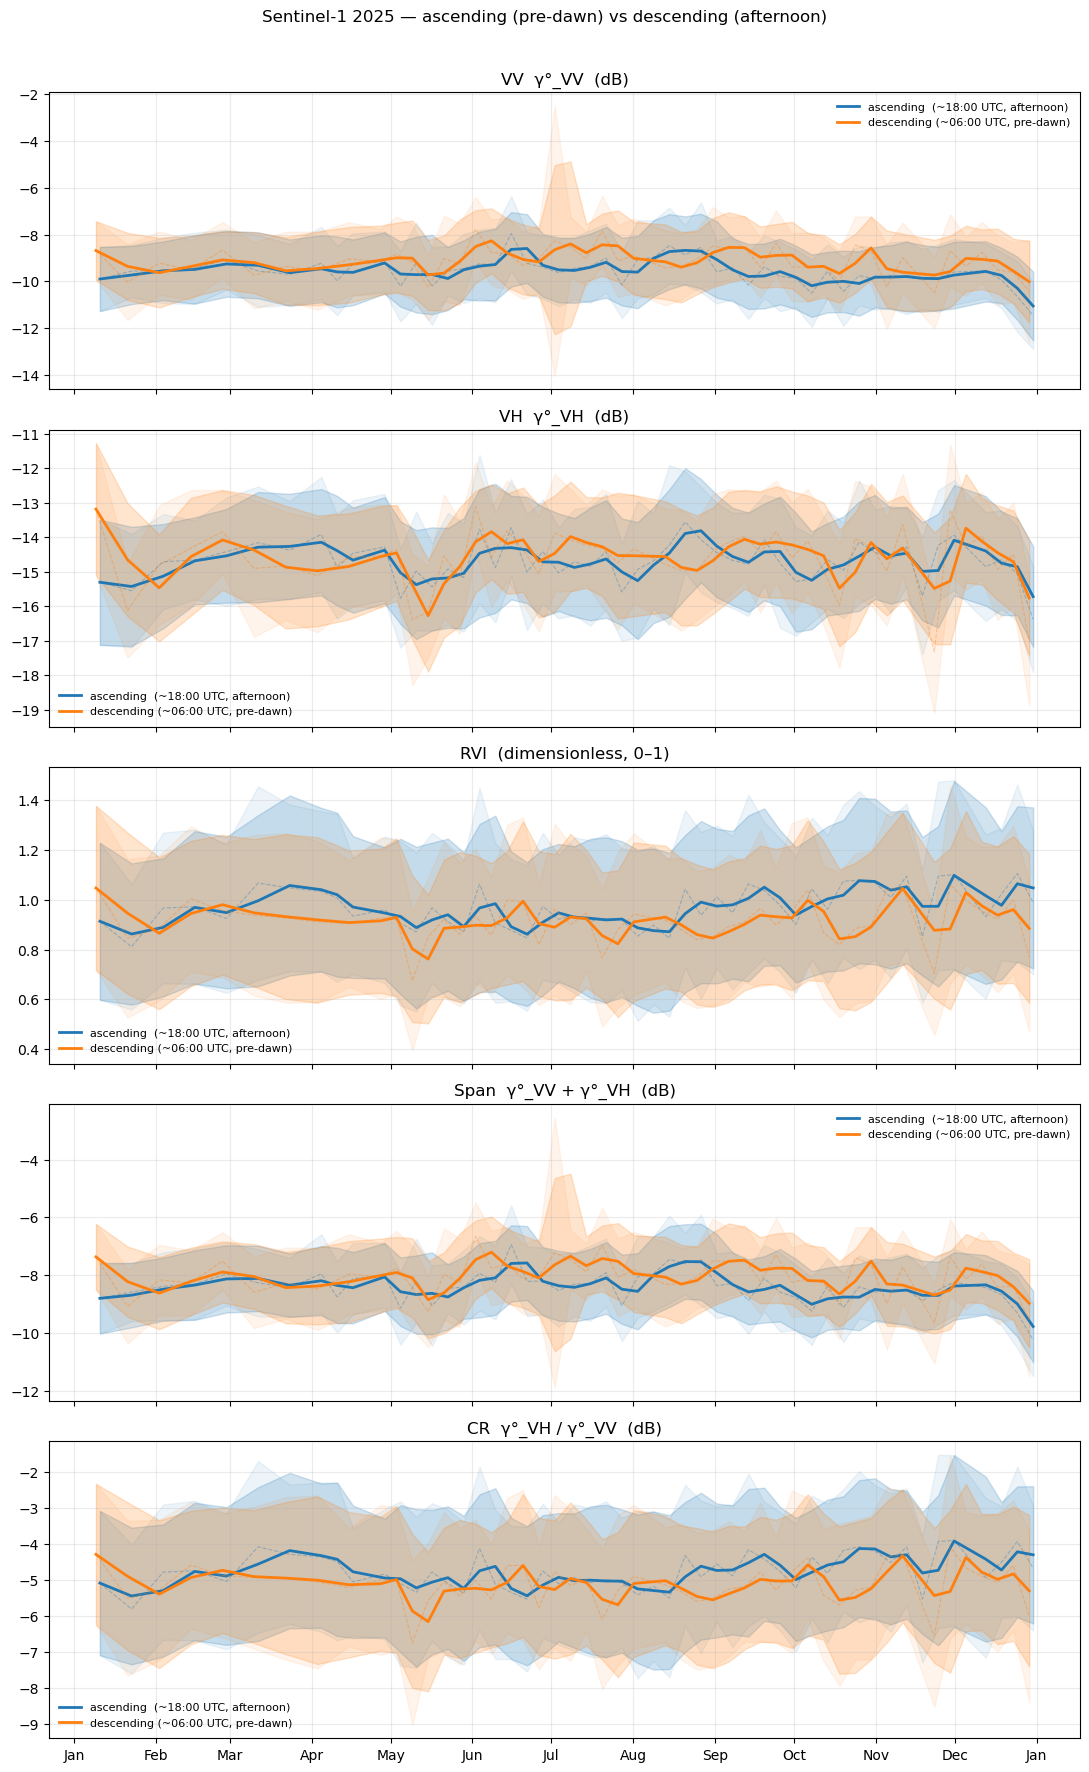

In [33]:
ORBIT_COLORS = {"ascending": "C0", "descending": "C1"}
ORBIT_NOTES  = {
    "ascending":  "ascending  (~18:00 UTC, afternoon)",
    "descending": "descending (~06:00 UTC, pre-dawn)",
}

S1_INDICES_PLOT = [
    ("VV_dB",   "VV  γ°_VV  (dB)"),
    ("VH_dB",   "VH  γ°_VH  (dB)"),
    ("RVI",     "RVI  (dimensionless, 0–1)"),
    ("SPAN_dB", "Span  γ°_VV + γ°_VH  (dB)"),
    ("CR_dB",   "CR  γ°_VH / γ°_VV  (dB)"),
]

SMOOTH_WINDOW = 2   # rolling median over 3 revisits (~18 days for S1)

fig, axes = plt.subplots(
    len(S1_INDICES_PLOT), 1,
    figsize=(11, 3.5 * len(S1_INDICES_PLOT)),
    sharex=True,
)

for ax, (idx_name, title) in zip(axes, S1_INDICES_PLOT):
    for orbit, color in ORBIT_COLORS.items():
        df = s1_stats_2025[orbit]
        if f"{idx_name}_mean" not in df.columns:
            continue
        t  = df.index
        m  = df[f"{idx_name}_mean"].astype(float)
        s  = df[f"{idx_name}_std"].astype(float)
        sm = m.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).median()

        finite_raw    = np.isfinite(m) & np.isfinite(s)
        finite_smooth = np.isfinite(sm) & np.isfinite(s)

        # faint raw ± std shading
        ax.fill_between(t, m - s, m + s, where=finite_raw, alpha=0.08, color=color)
        ax.plot(t, m,  lw=0.8, alpha=0.35, color=color, ls="--")

        # bold smoothed line + tighter shading
        s_smooth = s.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).median()
        ax.fill_between(t, sm - s_smooth, sm + s_smooth,
                        where=finite_smooth, alpha=0.2, color=color)
        ax.plot(t, sm, lw=2.0, color=color, label=ORBIT_NOTES[orbit])

    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

fig.suptitle("Sentinel-1 2025 — ascending (pre-dawn) vs descending (afternoon)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [60]:
asc = s1_stats_2025_dry["ascending"]["SPAN_dB_mean"]
desc = s1_stats_2025_dry["descending"]["SPAN_dB_mean"]

desc_on_asc_dates = desc.reindex(asc.index, method="nearest", tolerance="2D")
diff = asc - desc_on_asc_dates

stress_mask = (diff.index >= "2025-07-20") & (diff.index <= "2025-08-25")
print(f"non-stress asc-desc: {diff[~stress_mask].mean():+.2f} ± {diff[~stress_mask].std():.2f} dB")
print(f"stress     asc-desc: {diff[ stress_mask].mean():+.2f} ± {diff[ stress_mask].std():.2f} dB")

from scipy import stats
t, p = stats.ttest_ind(diff[~stress_mask].dropna(), diff[stress_mask].dropna())
print(f"t = {t:.2f}, p = {p:.4f}")

non-stress asc-desc: -0.29 ± 0.53 dB
stress     asc-desc: +0.86 ± nan dB
t = -2.14, p = 0.0435


In [64]:
print(ds_asc.time.dt.hour.values[:5])   # should be ~17-18
print(ds_desc.time.dt.hour.values[:5])  # should be ~5-6

[17 17 17 17 17]
[5 5 5 5 5]


## S1 scene inventory — rainfall (12 h prior) & RH (1 h prior)

In [34]:
import xarray as xr
import numpy as np
import pandas as pd

# ── 1. Collect all S1 acquisition timestamps across all years ─────────────
def get_all_s1_times(data_dir, orbit: str) -> pd.DatetimeIndex:
    """Load only the time coordinate from every yearly NetCDF for one orbit."""
    files = sorted(data_dir.glob(f"s1_grd_dehar_{orbit}_*.nc"))
    times = []
    for f in files:
        ds = xr.open_dataset(f)
        times.extend(pd.to_datetime(ds.time.values))
        ds.close()
    return pd.DatetimeIndex(sorted(times))

times_asc  = get_all_s1_times(sentinel_1_dir, "a")
times_desc = get_all_s1_times(sentinel_1_dir, "d")

print(f"Ascending   scenes: {len(times_asc)}  "
      f"({str(times_asc[0])[:10]} – {str(times_asc[-1])[:10]})")
print(f"Descending  scenes: {len(times_desc)}  "
      f"({str(times_desc[0])[:10]} – {str(times_desc[-1])[:10]})")

# ── 2. Prepare meteo & precip — strip tz, keep UTC-naive ─────────────────
def _strip_tz(s: pd.Series) -> pd.Series:
    idx = s.index
    if idx.tzinfo is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    return s.copy().set_axis(idx)

rh_series = _strip_tz(meteo["rh_pct"])
pr_series = _strip_tz(precip["Precipitation_Sum_mm"])

# ── 3. Windowed aggregates for a list of target timestamps ────────────────
def _windowed(series: pd.Series, times, window_h: float, agg: str) -> np.ndarray:
    """
    For each t in *times*, aggregate *series* over the half-open interval
    (t - window_h hours, t].  agg = 'sum' or 'mean'.
    """
    arr   = series.values.astype(float)
    idx_ns = series.index.asi8          # int64 nanoseconds
    delta_ns = int(pd.Timedelta(hours=window_h).value)
    out = np.full(len(times), np.nan)
    for i, t in enumerate(pd.DatetimeIndex(times)):
        t_ns = t.value
        lo = np.searchsorted(idx_ns, t_ns - delta_ns, side="right")
        hi = np.searchsorted(idx_ns, t_ns,             side="right")
        if hi > lo:
            chunk = arr[lo:hi]
            finite = chunk[np.isfinite(chunk)]
            if len(finite):
                out[i] = finite.sum() if agg == "sum" else finite.mean()
    return out

# ── 4. Build one DataFrame per orbit ─────────────────────────────────────
def build_scene_df(times: pd.DatetimeIndex, orbit_label: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "orbit":          orbit_label,
            "precip_12h_mm":  _windowed(pr_series, times, 12.0, "sum"),
            "rh_pct_1h_mean": _windowed(rh_series, times,  1.0, "mean"),
        },
        index=pd.DatetimeIndex(times, name="datetime"),
    )

df_s1_asc  = build_scene_df(times_asc,  "ascending")
df_s1_desc = build_scene_df(times_desc, "descending")

# ── 5. Coverage summary ───────────────────────────────────────────────────
for label, df in [("ascending", df_s1_asc), ("descending", df_s1_desc)]:
    n_pr = df["precip_12h_mm"].notna().sum()
    n_rh = df["rh_pct_1h_mean"].notna().sum()
    print(f"{label:12s}: {len(df)} scenes | "
          f"precip matched: {n_pr} | RH matched: {n_rh}")

print("\n── Ascending (rows with met data) ──────────────────────────────────")
display(df_s1_asc.dropna(how="all", subset=["precip_12h_mm", "rh_pct_1h_mean"]))

print("\n── Descending (rows with met data) ─────────────────────────────────")
display(df_s1_desc.dropna(how="all", subset=["precip_12h_mm", "rh_pct_1h_mean"]))


Ascending   scenes: 531  (2014-11-16 – 2026-04-05)
Descending  scenes: 495  (2014-10-10 – 2026-04-04)
ascending   : 531 scenes | precip matched: 51 | RH matched: 50
descending  : 495 scenes | precip matched: 49 | RH matched: 47

── Ascending (rows with met data) ──────────────────────────────────


,orbit,precip_12h_mm,rh_pct_1h_mean
datetime,,,
2024-12-05 17:24:12,ascending,NaN,90.3530
2024-12-17 17:24:11,ascending,NaN,91.9465
2024-12-29 17:24:10,ascending,NaN,96.3320
2025-01-10 17:24:09,ascending,0.00,88.1160
2025-01-22 17:24:08,ascending,0.38,96.4690
2025-02-03 17:24:08,ascending,0.00,84.6365
2025-02-15 17:24:07,ascending,0.00,78.9695
2025-02-27 17:24:07,ascending,1.40,90.9450
2025-03-11 17:24:07,ascending,0.00,71.9495



── Descending (rows with met data) ─────────────────────────────────


,orbit,precip_12h_mm,rh_pct_1h_mean
datetime,,,
2024-12-04 05:35:18,descending,NaN,95.0740
2024-12-16 05:35:17,descending,NaN,75.2750
2024-12-28 05:35:16,descending,NaN,92.8050
2025-01-09 05:35:15,descending,1.65,69.0605
2025-01-21 05:35:14,descending,0.00,95.2480
2025-02-02 05:35:13,descending,0.00,90.3140
2025-02-14 05:35:13,descending,0.10,92.9330
2025-02-26 05:35:13,descending,0.00,84.2080
2025-03-10 05:35:13,descending,0.00,80.1565
